<a href="https://colab.research.google.com/github/amit20kr/coalrock-classifier/blob/main/coalrock_preprocess2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***SETUP & IMPORTS: PREPROCESSING***

In [10]:
# CELL 1 — SETUP, IMPORTS & DRIVE MOUNT
import os, glob, time, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from sklearn.preprocessing import LabelEncoder
import torch
from google.colab import drive

drive.mount('/content/drive')

print(f"PyTorch : {torch.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"Pandas  : {pd.__version__}")

# PATHS
PROJECT_ROOT    = "/content/drive/MyDrive/coalrock_project2"
RAW_DATA_SOURCE = os.path.join(PROJECT_ROOT, "Spectroscopy_dataset", "Spectra")
PROCESSED_PATH  = os.path.join(PROJECT_ROOT, "processed_data")
MODELS_PATH     = os.path.join(PROJECT_ROOT, "models")
RESULTS_PATH    = os.path.join(PROJECT_ROOT, "results")

for d in [PROCESSED_PATH, MODELS_PATH, RESULTS_PATH]:
    os.makedirs(d, exist_ok=True)
    print(f"Ready: {d}")

# 24 CLASSES (12 Coal + 12 Rock)
TARGET_CLASSES = [
    # Coal — FUEL
    'Anthracite coal grade 1', 'Anthracite coal grade 2',
    'Lean coal', 'Lean-thin coal', 'Thin coal',
    'Coking coal', '0.3 coking coal',
    'Fat coal', 'Gas-fat coal', 'Gas coal',
    'Lignite coal grade 1', 'Lignite coal grade 2',
    # Rock — GANGUE
    'Black shale 1', 'Black shale 2', 'Carbonaceous shale',
    'Arenaceous shale 1', 'Arenaceous shale 2', 'Clay',
    'Siltstone 1', 'Siltstone 2',
    'Fine-grained sandstone', 'Medium-grained sandstone',
    'Argillaceous limestone 1', 'Argillaceous limestone 2',
]

# Sorted longest-first to prevent "Lean coal" matching inside "Lean-thin coal"
SORTED_CLASSES = sorted(TARGET_CLASSES, key=len, reverse=True)

le = LabelEncoder().fit(TARGET_CLASSES)

print(f"\nClasses : {len(TARGET_CLASSES)}")
print("Encoder mapping (alphabetical, what model outputs as integer IDs):")
for i, cls in enumerate(le.classes_):
    print(f"  {i:>2}: {cls}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PyTorch : 2.11.0+cpu
NumPy   : 2.0.2
Pandas  : 2.2.2
Ready: /content/drive/MyDrive/coalrock_project2/processed_data
Ready: /content/drive/MyDrive/coalrock_project2/models
Ready: /content/drive/MyDrive/coalrock_project2/results

Classes : 24
Encoder mapping (alphabetical, what model outputs as integer IDs):
   0: 0.3 coking coal
   1: Anthracite coal grade 1
   2: Anthracite coal grade 2
   3: Arenaceous shale 1
   4: Arenaceous shale 2
   5: Argillaceous limestone 1
   6: Argillaceous limestone 2
   7: Black shale 1
   8: Black shale 2
   9: Carbonaceous shale
  10: Clay
  11: Coking coal
  12: Fat coal
  13: Fine-grained sandstone
  14: Gas coal
  15: Gas-fat coal
  16: Lean coal
  17: Lean-thin coal
  18: Lignite coal grade 1
  19: Lignite coal grade 2
  20: Medium-grained sandstone
  21: Siltstone 1
  22: Siltstone 2
  23: Thin coal


***DATA INGESTION***

In [11]:
# CELL 2 — RAW DATA INGESTION (surgical_load v3)

EXPECTED_BANDS = 1500
REFLECTANCE_MAX = 900


def surgical_load(filepath):

    try:
        df = pd.read_csv(filepath, header=None, low_memory=False)
        df_num = df.apply(pd.to_numeric, errors='coerce')

        # Drop metadata rows
        df_clean = df_num.dropna(axis=0, thresh=df.shape[1] * 0.5)
        vals = df_clean.values

        if vals.size == 0:
            return None

        # Distance-heuristic transpose.
        if abs(vals.shape[0] - EXPECTED_BANDS) < abs(vals.shape[1] - EXPECTED_BANDS):
            vals = vals.T
        # vals is now (N_samples [+1 if wavelength col present], N_bands)

        # Wavelength Assassin.
        if vals.shape[0] > 0 and not np.isnan(vals[0, 0]) and vals[0, 0] >= REFLECTANCE_MAX:
            vals = vals[1:, :]   # Strip the wavelength row

        if vals.shape[0] == 0:
            return None

        # Front-crop to exactly 1500 bands.
        if vals.shape[1] > EXPECTED_BANDS:
            vals = vals[:, :EXPECTED_BANDS]

        if vals.shape[1] != EXPECTED_BANDS:
            print(f"    Skip {os.path.basename(filepath)}: "
                  f"band count = {vals.shape[1]} after crop (expected {EXPECTED_BANDS})")
            return None

        return vals.astype(np.float32)

    except Exception as e:
        print(f"    Error loading {os.path.basename(filepath)}: {e}")
        return None


# LOAD ALL CSVs
print(f"Starting ingestion from: {RAW_DATA_SOURCE}\n")

all_csvs = glob.glob(os.path.join(RAW_DATA_SOURCE, "*.csv"))
if not all_csvs:
    # Fallback: scan entire Drive
    print("  No CSVs found in RAW_DATA_SOURCE. Scanning Drive (slow)...")
    all_csvs = glob.glob("/content/drive/MyDrive/**/*.csv", recursive=True)
    all_csvs = [f for f in all_csvs if "Spectra" in f]

print(f"Found {len(all_csvs)} CSV files.\n")

raw_data_buffer = []   # List of (class_name: str, data: ndarray (N, 1500))
skipped_files   = []

for filepath in sorted(all_csvs):
    basename   = os.path.basename(filepath)
    clean_name = basename.lower().replace(" ", "").replace("_", "").replace("-", "")

    found_cls = None

    if "03coking" in clean_name or "13coking" in clean_name:
        # "0.3 coking coal.csv" → "03cokingcoal"
        found_cls = '0.3 coking coal'
    elif "gasfat" in clean_name:
        # "Gas fat coal.csv" → "gasfatcoal" (must come before "gas coal" check)
        found_cls = 'Gas-fat coal'
    elif "thin" in clean_name and "coal" in clean_name and "lean" not in clean_name:
        # "Thin coal.csv" — exclude "lean" to avoid matching "Lean-thin coal"
        found_cls = 'Thin coal'
    else:
        # General: longest match first prevents substring collisions
        for cls in SORTED_CLASSES:
            clean_cls = cls.lower().replace(" ", "").replace("-", "")
            if clean_cls in clean_name:
                found_cls = cls
                break

    if found_cls is None:
        skipped_files.append(basename)
        continue

    data = surgical_load(filepath)
    if data is not None:
        raw_data_buffer.append((found_cls, data))
        print(f"  ✓  {basename:<45} → '{found_cls}' [{data.shape[0]} samples]")
    else:
        skipped_files.append(basename)

# INGESTION REPORT
total_raw     = sum(d.shape[0] for _, d in raw_data_buffer)
found_classes = {c for c, _ in raw_data_buffer}
missing       = set(TARGET_CLASSES) - found_classes

print(f"\n{'='*60}")
print(f"Files loaded  : {len(raw_data_buffer)} / {len(all_csvs)}")
print(f"Files skipped : {len(skipped_files)}")
if skipped_files:
    print(f"  Skipped: {skipped_files}")
print(f"Total samples : {total_raw}")
print(f"Classes found : {len(found_classes)} / 24")

if missing:
    print(f"\n⚠  MISSING CLASSES — fix filenames before continuing:")
    for m in sorted(missing):
        print(f"   → {m}")
else:
    print("\nAll 24 classes loaded.")


Starting ingestion from: /content/drive/MyDrive/coalrock_project2/Spectroscopy_dataset/Spectra

Found 24 CSV files.

  ✓  0.3 coking coal.csv                           → '0.3 coking coal' [419 samples]
  ✓  Anthracite coal grade 1.csv                   → 'Anthracite coal grade 1' [419 samples]
  ✓  Anthracite coal grade 2.csv                   → 'Anthracite coal grade 2' [419 samples]
  ✓  Arenaceous shale 1.csv                        → 'Arenaceous shale 1' [343 samples]
  ✓  Arenaceous shale 2.csv                        → 'Arenaceous shale 2' [441 samples]
  ✓  Argillaceous limestone 1.csv                  → 'Argillaceous limestone 1' [419 samples]
  ✓  Argillaceous limestone 2.csv                  → 'Argillaceous limestone 2' [584 samples]
  ✓  Black shale 1.csv                             → 'Black shale 1' [343 samples]
  ✓  Black shale 2.csv                             → 'Black shale 2' [419 samples]
  ✓  Carbonaceous shale.csv                        → 'Carbonaceous shale' [419 sam

***REMOVING DUPLICATE***

In [12]:
# CELL 3 — DEDUPLICATION (float-precision-safe)

print("Running deduplication (rounded-hash, float-precision-safe)...")
start = time.time()

unique_store     = {}   # rounded_bytes → (spectral_row, class_id)
duplicates_found = 0

for cls_name, data_array in raw_data_buffer:
    cls_id = le.transform([cls_name])[0]

    for row in data_array:
        h = np.round(row, decimals=4).tobytes()
        if h not in unique_store:
            unique_store[h] = (row, cls_id)
        else:
            duplicates_found += 1

clean_X = np.array([v[0] for v in unique_store.values()], dtype=np.float32)
clean_y = np.array([v[1] for v in unique_store.values()], dtype=np.int64)

elapsed = time.time() - start
print(f"Done in {elapsed:.1f}s")
print(f"  Original samples  : {total_raw}")
print(f"  Duplicates removed: {duplicates_found}")
print(f"  Unique samples    : {len(clean_X)}")

# Per-class sample count
print("\nSamples per class after deduplication:")
for cls_id, cls_name in enumerate(le.classes_):
    n = int((clean_y == cls_id).sum())
    bar = '█' * (n // 20)
    print(f"  {cls_id:>2}  {cls_name:<32} {n:>5}  {bar}")


Running deduplication (rounded-hash, float-precision-safe)...
Done in 0.2s
  Original samples  : 10520
  Duplicates removed: 23
  Unique samples    : 10497

Samples per class after deduplication:
   0  0.3 coking coal                    419  ████████████████████
   1  Anthracite coal grade 1            418  ████████████████████
   2  Anthracite coal grade 2            418  ████████████████████
   3  Arenaceous shale 1                 342  █████████████████
   4  Arenaceous shale 2                 440  ██████████████████████
   5  Argillaceous limestone 1           418  ████████████████████
   6  Argillaceous limestone 2           583  █████████████████████████████
   7  Black shale 1                      342  █████████████████
   8  Black shale 2                      418  ████████████████████
   9  Carbonaceous shale                 418  ████████████████████
  10  Clay                               583  █████████████████████████████
  11  Coking coal                        418  ███████

***TRAIN-VAL-TEST***

In [13]:
# CELL 4 — STRATIFIED 3-WAY SPLIT (Train 70 / Val 15 / Test 15)

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
# TEST_RATIO = 0.15

print("Running per-class stratified split (seed=42)...")
np.random.seed(42)

X_train_l, y_train_l = [], []
X_val_l,   y_val_l   = [], []
X_test_l,  y_test_l  = [], []

for cls_id in range(len(le.classes_)):
    mask    = (clean_y == cls_id)
    samples = clean_X[mask]
    n       = len(samples)

    if n == 0:
        print(f"   Class {le.classes_[cls_id]} has 0 samples — check ingestion.")
        continue

    # Shuffle within-class before splitting
    perm    = np.random.permutation(n)
    samples = samples[perm]

    # Cut points — guarantee at least 1 sample per split
    n_train = max(1, int(round(n * TRAIN_RATIO)))
    n_val   = max(1, int(round(n * VAL_RATIO)))
    n_train = min(n_train, n - 2)
    n_val   = min(n_val,   n - n_train - 1)
    n_test  = n - n_train - n_val

    X_train_l.append(samples[:n_train])
    y_train_l.extend([cls_id] * n_train)

    X_val_l.append(samples[n_train : n_train + n_val])
    y_val_l.extend([cls_id] * n_val)

    X_test_l.append(samples[n_train + n_val :])
    y_test_l.extend([cls_id] * n_test)

X_train_raw = np.concatenate(X_train_l, axis=0)
y_train     = np.array(y_train_l, dtype=np.int64)
X_val_raw   = np.concatenate(X_val_l, axis=0)
y_val       = np.array(y_val_l, dtype=np.int64)
X_test_raw  = np.concatenate(X_test_l, axis=0)
y_test      = np.array(y_test_l, dtype=np.int64)

total = len(clean_X)
print(f"\nSplit complete (seed=42, total={total}):")
print(f"  Train : {len(X_train_raw):>5} samples  ({len(X_train_raw)/total*100:.1f}%)")
print(f"  Val   : {len(X_val_raw):>5} samples  ({len(X_val_raw)/total*100:.1f}%)")
print(f"  Test  : {len(X_test_raw):>5} samples  ({len(X_test_raw)/total*100:.1f}%)")
print(f"  Classes in train : {len(np.unique(y_train))} / 24")
print(f"  Classes in val   : {len(np.unique(y_val))} / 24")
print(f"  Classes in test  : {len(np.unique(y_test))} / 24")


Running per-class stratified split (seed=42)...

Split complete (seed=42, total=10497):
  Train :  7353 samples  (70.0%)
  Val   :  1578 samples  (15.0%)
  Test  :  1566 samples  (14.9%)
  Classes in train : 24 / 24
  Classes in val   : 24 / 24
  Classes in test  : 24 / 24


***SIGNAL PROCESSING***

Applying 3-channel signal processing to all splits...
Done in 0.80s

Final tensor shapes (all must be [N, 3, 1500]):
  X_train_final : (7353, 3, 1500)
  X_val_final   : (1578, 3, 1500)
  X_test_final  : (1566, 3, 1500)


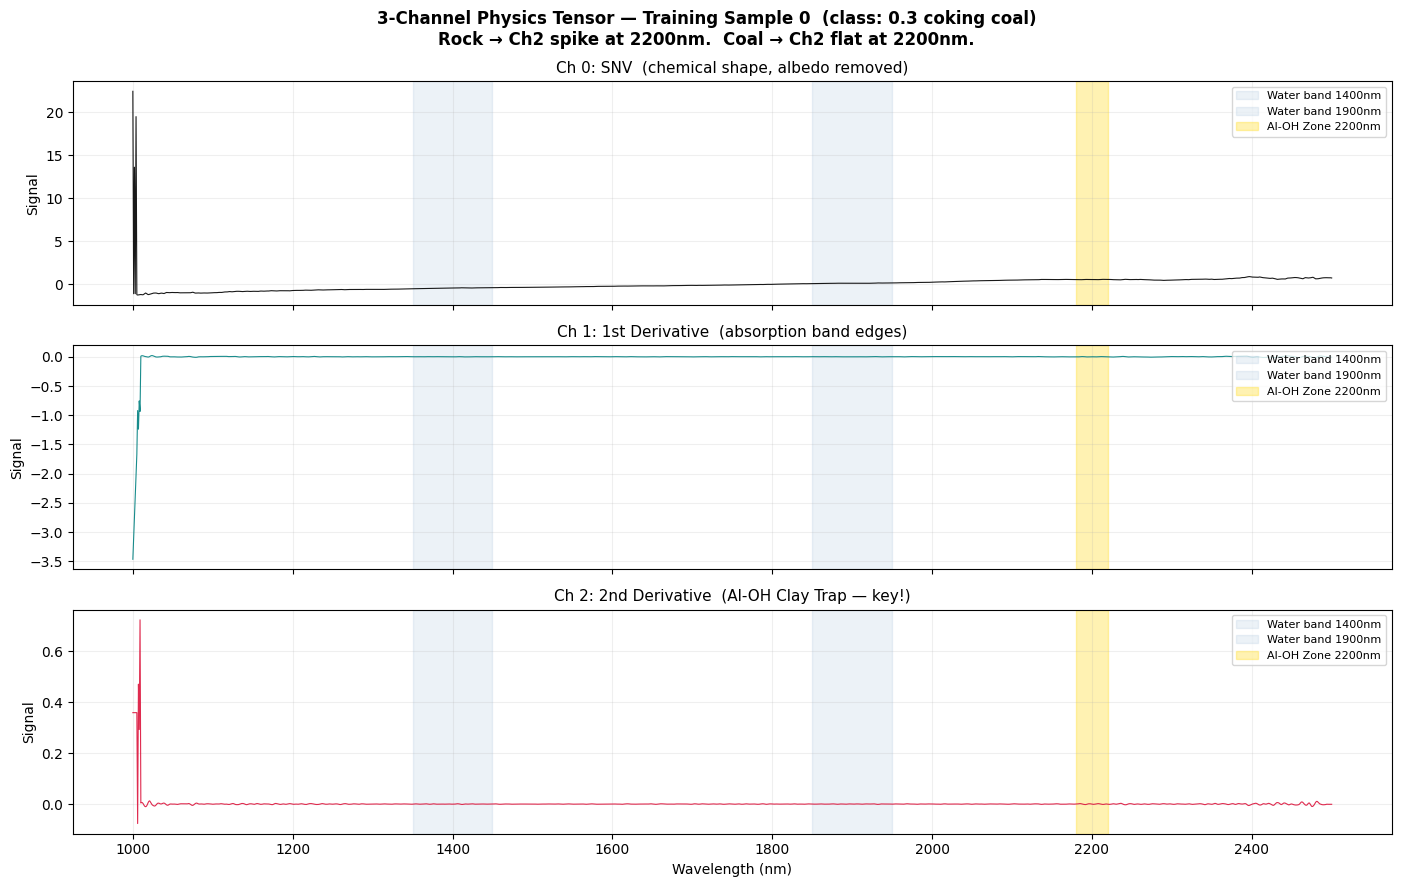

In [14]:
# CELL 5 — SIGNAL PROCESSING: 3-CHANNEL PHYSICS TENSOR

def process_signals(X_in):
    """
    Input:  np.float32 (N, 1500)
    Output: np.float32 (N, 3, 1500)  —  [Ch0_SNV, Ch1_d1, Ch2_d2]
    """
    X_in = np.nan_to_num(X_in, nan=0.0)    # Guard: replace stray NaN with 0

    # Channel 0: SNV — per-sample z-score across wavelength axis
    mean  = X_in.mean(axis=1, keepdims=True)
    std   = X_in.std(axis=1,  keepdims=True)
    X_snv = (X_in - mean) / (std + 1e-8)

    # Channels 1 & 2: Savitzky-Golay on the SNV signal
    # axis=1 → derivative along wavelengths for each sample independently
    X_d1 = savgol_filter(X_snv, window_length=11, polyorder=2, deriv=1, axis=1)
    X_d2 = savgol_filter(X_snv, window_length=11, polyorder=2, deriv=2, axis=1)

    # Stack → (N, 3, 1500)
    return np.stack([X_snv, X_d1, X_d2], axis=1).astype(np.float32)


print("Applying 3-channel signal processing to all splits...")
start = time.time()

X_train_final = process_signals(X_train_raw)
X_val_final   = process_signals(X_val_raw)
X_test_final  = process_signals(X_test_raw)

elapsed = time.time() - start
print(f"Done in {elapsed:.2f}s")
print(f"\nFinal tensor shapes (all must be [N, 3, 1500]):")
print(f"  X_train_final : {X_train_final.shape}")
print(f"  X_val_final   : {X_val_final.shape}")
print(f"  X_test_final  : {X_test_final.shape}")

# PHYSICS VERIFICATION PLOT
WAVELENGTHS = np.linspace(1000, 2500, EXPECTED_BANDS)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
sample_cls = le.inverse_transform([y_train[0]])[0]
fig.suptitle(
    f"3-Channel Physics Tensor — Training Sample 0  (class: {sample_cls})\n"
    "Rock → Ch2 spike at 2200nm.  Coal → Ch2 flat at 2200nm.",
    fontsize=12, fontweight='bold'
)

channel_cfg = [
    (0, "Ch 0: SNV  (chemical shape, albedo removed)",       "black"),
    (1, "Ch 1: 1st Derivative  (absorption band edges)",     "teal"),
    (2, "Ch 2: 2nd Derivative  (Al-OH Clay Trap — key!)",   "crimson"),
]

for ax, (ch, title, color) in zip(axes, channel_cfg):
    ax.plot(WAVELENGTHS, X_train_final[0, ch], color=color, lw=0.8, alpha=0.9)
    ax.axvspan(1350, 1450, color='steelblue', alpha=0.10, label='Water band 1400nm')
    ax.axvspan(1850, 1950, color='steelblue', alpha=0.10, label='Water band 1900nm')
    ax.axvspan(2180, 2220, color='gold',      alpha=0.30, label='Al-OH Zone 2200nm')
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Signal")
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=8, loc='upper right')

axes[-1].set_xlabel("Wavelength (nm)")
plt.tight_layout()
plt.show()


In [15]:
# CELL 6 — LEAKAGE AUDIT (all 3 split-pairs, processed arrays)

print("Running 3-pair leakage audit on processed tensors...")
start = time.time()

train_hashes = {x.tobytes() for x in X_train_final}
val_hashes   = {x.tobytes() for x in X_val_final}
test_hashes  = {x.tobytes() for x in X_test_final}

train_val_overlap  = len(train_hashes & val_hashes)
train_test_overlap = len(train_hashes & test_hashes)
val_test_overlap   = len(val_hashes   & test_hashes)

elapsed = time.time() - start
print(f"Done in {elapsed:.1f}s")
print(f"  Train ∩ Val  : {train_val_overlap}")
print(f"  Train ∩ Test : {train_test_overlap}")
print(f"  Val   ∩ Test : {val_test_overlap}")

total_overlap = train_val_overlap + train_test_overlap + val_test_overlap
if total_overlap == 0:
    print("\n✅ AUDIT PASSED — 0% leakage. All three splits are disjoint.")
else:
    msg = (
        f"DATA LEAKAGE: {total_overlap} overlapping processed samples.\n"
        f"  Train∩Val={train_val_overlap}  Train∩Test={train_test_overlap}  Val∩Test={val_test_overlap}\n"
        f"  Fix: re-run Cell 4 with a different seed."
    )
    print(f"\n❌ {msg}")
    raise RuntimeError(msg)


Running 3-pair leakage audit on processed tensors...
Done in 0.1s
  Train ∩ Val  : 0
  Train ∩ Test : 0
  Val   ∩ Test : 0

✅ AUDIT PASSED — 0% leakage. All three splits are disjoint.


***SAVING TO DRIVE***

In [16]:
# CELL 7 — ATOMIC SAVE TO DRIVE

print("Saving all outputs to Drive...")
start = time.time()

np.save(os.path.join(PROCESSED_PATH, 'X_train.npy'), X_train_final)
np.save(os.path.join(PROCESSED_PATH, 'y_train.npy'), y_train)
print(f"  ✓ X_train.npy  {X_train_final.shape}")

np.save(os.path.join(PROCESSED_PATH, 'X_val.npy'), X_val_final)
np.save(os.path.join(PROCESSED_PATH, 'y_val.npy'), y_val)
print(f"  ✓ X_val.npy    {X_val_final.shape}")

np.save(os.path.join(PROCESSED_PATH, 'X_test.npy'), X_test_final)
np.save(os.path.join(PROCESSED_PATH, 'y_test.npy'), y_test)
print(f"  ✓ X_test.npy   {X_test_final.shape}")

# Save encoder to both locations in one block
for save_dir, label in [(PROCESSED_PATH, "processed_data"), (MODELS_PATH, "models")]:
    with open(os.path.join(save_dir, 'label_encoder.pkl'), 'wb') as f:
        pickle.dump(le, f)
    print(f"  ✓ label_encoder.pkl  → {label}/")

elapsed = time.time() - start
print(f"\nAll files saved in {elapsed:.1f}s → {PROJECT_ROOT}")


Saving all outputs to Drive...
  ✓ X_train.npy  (7353, 3, 1500)
  ✓ X_val.npy    (1578, 3, 1500)
  ✓ X_test.npy   (1566, 3, 1500)
  ✓ label_encoder.pkl  → processed_data/
  ✓ label_encoder.pkl  → models/

All files saved in 1.1s → /content/drive/MyDrive/coalrock_project2


***VERIFICATION***

In [17]:
# CELL 8 — POST-SAVE INTEGRITY VERIFICATION (from disk)

print("Reloading all saved files from disk...\n")

_pd = PROCESSED_PATH
_md = MODELS_PATH

_X_tr = np.load(os.path.join(_pd, 'X_train.npy'))
_y_tr = np.load(os.path.join(_pd, 'y_train.npy'))
_X_v  = np.load(os.path.join(_pd, 'X_val.npy'))
_y_v  = np.load(os.path.join(_pd, 'y_val.npy'))
_X_te = np.load(os.path.join(_pd, 'X_test.npy'))
_y_te = np.load(os.path.join(_pd, 'y_test.npy'))

with open(os.path.join(_pd, 'label_encoder.pkl'), 'rb') as f:
    _le_proc = pickle.load(f)
with open(os.path.join(_md, 'label_encoder.pkl'), 'rb') as f:
    _le_mod  = pickle.load(f)

passed = 0
failed = 0

def chk(cond, ok_msg, fail_msg):
    global passed, failed
    if cond:
        print(f"  ✓ {ok_msg}")
        passed += 1
    else:
        print(f"  ✗ FAIL: {fail_msg}")
        failed += 1

# Shape checks — all must be (N, 3, 1500)
chk(_X_tr.shape[1:] == (3, 1500), f"X_train {_X_tr.shape}", f"X_train wrong: {_X_tr.shape}")
chk(_X_v.shape[1:]  == (3, 1500), f"X_val   {_X_v.shape}",  f"X_val wrong:   {_X_v.shape}")
chk(_X_te.shape[1:] == (3, 1500), f"X_test  {_X_te.shape}", f"X_test wrong:  {_X_te.shape}")

# Band count — confirm front-crop
chk(_X_tr.shape[2] == 1500, "Band count = 1500 (front-crop confirmed)", f"Wrong band count: {_X_tr.shape[2]}")

# Label/feature alignment
chk(len(_y_tr) == len(_X_tr), f"y_train len={len(_y_tr)} matches X_train", "Train length mismatch")
chk(len(_y_v)  == len(_X_v),  f"y_val   len={len(_y_v)}  matches X_val",   "Val length mismatch")
chk(len(_y_te) == len(_X_te), f"y_test  len={len(_y_te)} matches X_test",  "Test length mismatch")

# Label ranges
chk(_y_tr.min() >= 0 and _y_tr.max() <= 23, f"Train labels [0,23]: min={_y_tr.min()} max={_y_tr.max()}", "Train label range error")
chk(_y_v.min()  >= 0 and _y_v.max()  <= 23, f"Val   labels [0,23]: min={_y_v.min()}  max={_y_v.max()}",  "Val label range error")
chk(_y_te.min() >= 0 and _y_te.max() <= 23, f"Test  labels [0,23]: min={_y_te.min()} max={_y_te.max()}", "Test label range error")

# All 24 classes in every split
chk(len(np.unique(_y_tr)) == 24, f"Train has all 24 classes", f"Train missing {24 - len(np.unique(_y_tr))} classes")
chk(len(np.unique(_y_v))  == 24, f"Val   has all 24 classes", f"Val   missing {24 - len(np.unique(_y_v))}  classes")
chk(len(np.unique(_y_te)) == 24, f"Test  has all 24 classes", f"Test  missing {24 - len(np.unique(_y_te))} classes")

# Encoder sanity
chk(len(_le_proc.classes_) == 24, f"Encoder (processed_data) has 24 classes", f"Encoder has {len(_le_proc.classes_)}")
chk(list(_le_proc.classes_) == list(_le_mod.classes_),
    "Both encoder copies match (processed_data/ == models/)",
    "ENCODER MISMATCH between locations — resave immediately")

# Val ≠ Test (no contamination from original val=test bug)
_v_hashes  = {x.tobytes() for x in _X_v}
_te_hashes = {x.tobytes() for x in _X_te}
chk(len(_v_hashes & _te_hashes) == 0,
    "Val and Test are disjoint (val ≠ test confirmed)",
    f"Val/Test overlap: {len(_v_hashes & _te_hashes)} samples")

# --- FINAL REPORT ---
print(f"\n{'='*55}")
if failed == 0:
    print(f"✅  ALL {passed} CHECKS PASSED — preprocessing is complete.")
    print(f"\nReady for training notebook:")
    print(f"  Torch version for requirements.txt: {torch.__version__}")
    print(f"  X_train: {_X_tr.shape}  y_train: {_y_tr.shape}")
    print(f"  X_val:   {_X_v.shape}   y_val:   {_y_v.shape}")
    print(f"  X_test:  {_X_te.shape}  y_test:  {_y_te.shape}")
    print(f"  Encoder: {list(_le_proc.classes_)}")
    print(f"  Saved to: {PROJECT_ROOT}")
else:
    print(f"❌  {failed}/{passed+failed} CHECKS FAILED — do not proceed to training.")


Reloading all saved files from disk...

  ✓ X_train (7353, 3, 1500)
  ✓ X_val   (1578, 3, 1500)
  ✓ X_test  (1566, 3, 1500)
  ✓ Band count = 1500 (front-crop confirmed)
  ✓ y_train len=7353 matches X_train
  ✓ y_val   len=1578  matches X_val
  ✓ y_test  len=1566 matches X_test
  ✓ Train labels [0,23]: min=0 max=23
  ✓ Val   labels [0,23]: min=0  max=23
  ✓ Test  labels [0,23]: min=0 max=23
  ✓ Train has all 24 classes
  ✓ Val   has all 24 classes
  ✓ Test  has all 24 classes
  ✓ Encoder (processed_data) has 24 classes
  ✓ Both encoder copies match (processed_data/ == models/)
  ✓ Val and Test are disjoint (val ≠ test confirmed)

✅  ALL 16 CHECKS PASSED — preprocessing is complete.

Ready for training notebook:
  Torch version for requirements.txt: 2.11.0+cpu
  X_train: (7353, 3, 1500)  y_train: (7353,)
  X_val:   (1578, 3, 1500)   y_val:   (1578,)
  X_test:  (1566, 3, 1500)  y_test:  (1566,)
  Encoder: [np.str_('0.3 coking coal'), np.str_('Anthracite coal grade 1'), np.str_('Anthracite